# Omni3D / Cube R-CNN — 3D кубоиды на своём видео (Google Colab)

Демо по [Omni3D](https://github.com/facebookresearch/omni3d#demo): монокулярная детекция 3D-объектов (кубоиды) на кадрах из вашего видео.

**Перед запуском:** `Среда выполнения` → `Сменить среду выполнения` → **GPU** (T4 достаточно).

Порядок: ячейки установки → **перезапуск среды** → остальные ячейки по порядку.

На новом Colab (Python 3.12) инференс идёт через отдельный **Python 3.10 venv** — это нормально.


In [1]:
!rm -f /content/omni3d/.colab_deps_ok
!rm -rf /content/cubercnn_venv /content/detectron2 /content/pytorch3d

## 0. Проверка GPU

In [2]:
import torch

assert torch.cuda.is_available(), (
    "Нужен GPU: Среда выполнения → Сменить среду выполнения → T4 (или лучше)."
)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)

CUDA: 12.8
GPU: Tesla T4
PyTorch: 2.11.0+cu128


## 1. Клонирование Omni3D и установка зависимостей

Colab (CUDA 12.x) → **venv Python 3.10** + **PyTorch cu124** + сборка Detectron2 с обходом проверки версии CUDA.

После успеха: **Runtime → Restart session** → раздел **2**.

При ошибке: `!rm -f /content/omni3d/.colab_deps_ok && rm -rf /content/cubercnn_venv /content/detectron2`


In [3]:
import os
import sys
import subprocess
import re

OMNI3D_DIR = "/content/omni3d"
D2_DIR = "/content/detectron2"
MARKER = os.path.join(OMNI3D_DIR, ".colab_deps_ok")
PY_CONFIG = "/content/omni3d_python.txt"
VENV_DIR = "/content/cubercnn_venv"
CONSTRAINTS = "/content/omni3d_constraints.txt"
WHEEL_BASE = "https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels"


def run(cmd, check=True):
    print("$", " ".join(cmd) if isinstance(cmd, list) else cmd)
    if isinstance(cmd, str):
        return subprocess.run(cmd, shell=True, check=check)
    return subprocess.run(cmd, check=check)


def pip_run(*args, check=False):
    r = subprocess.run([PY, "-m", "pip", *args], capture_output=True, text=True)
    if r.stdout.strip():
        print(r.stdout[-3000:])
    if r.stderr.strip() and r.returncode != 0:
        print(r.stderr[-3000:])
    if check and r.returncode != 0:
        raise subprocess.CalledProcessError(r.returncode, r.args, r.stdout, r.stderr)
    return r.returncode == 0


def ensure_runtime_python():
    if sys.version_info >= (3, 12):
        print(f"Colab Python {sys.version.split()[0]} → venv Python 3.10")
        run(["apt-get", "-qq", "update"], check=False)
        run(
            [
                "apt-get", "-qq", "install", "-y",
                "python3.10", "python3.10-venv", "python3.10-dev",
                "build-essential", "ninja-build",
            ],
            check=True,
        )
        py310 = "/usr/bin/python3.10"
        if not os.path.isfile(py310):
            py310 = "python3.10"
        if not os.path.isfile(os.path.join(VENV_DIR, "bin", "python")):
            run([py310, "-m", "venv", VENV_DIR], check=True)
        return os.path.join(VENV_DIR, "bin", "python")
    return sys.executable


def system_cuda_version():
    try:
        out = subprocess.check_output(["nvcc", "--version"], text=True)
        m = re.search(r"release (\d+\.\d+)", out)
        return m.group(1) if m else ""
    except Exception:
        return ""


PY = ensure_runtime_python()
with open(PY_CONFIG, "w") as f:
    f.write(PY)
print("Python для Omni3D:", PY)
print("CUDA (nvcc):", system_cuda_version() or "unknown")

with open(CONSTRAINTS, "w") as f:
    f.write("numpy<2\n")


def torch_env():
    code = (
        "import sys, torch; "
        "print(torch.__version__); "
        "print(torch.version.cuda or ''); "
        "print(sys.version_info.minor)"
    )
    out = subprocess.check_output([PY, "-c", code], text=True).strip().splitlines()
    return out[0], out[1], int(out[2])


def import_ok():
    code = "import detectron2, pytorch3d; print('OK')"
    return subprocess.run([PY, "-c", code], capture_output=True, text=True).returncode == 0


def pytorch3d_wheel_tags():
    pyt, cuda, py = torch_env()
    cuda = cuda.replace(".", "")
    ver_tag = pyt.split("+")[0].replace(".", "")
    tags = [f"py3{py}_cu{cuda}_pyt{ver_tag}"]
    for alt in ("241", "240", "251", "210", "211"):
        t = f"py3{py}_cu{cuda}_pyt{alt}"
        if t not in tags:
            tags.append(t)
    # соседние CUDA-теги
    for cu in ("124", "121", "118"):
        t = f"py3{py}_cu{cu}_pyt{ver_tag}"
        if t not in tags:
            tags.append(t)
    return tags


def install_pytorch3d_wheel():
    for tag in pytorch3d_wheel_tags():
        url = f"{WHEEL_BASE}/{tag}/download.html"
        for ver in ("0.7.5", "0.7.8", ""):
            spec = f"pytorch3d=={ver}" if ver else "pytorch3d"
            print("PyTorch3D wheel:", tag, ver or "latest")
            if pip_run("install", "--no-index", "--no-cache-dir", spec, "-f", url):
                return True
    return False


def install_pytorch3d_source():
    print("Сборка PyTorch3D v0.7.5 (~10–15 мин)...")
    p3d_dir = "/content/pytorch3d"
    if os.path.isdir(p3d_dir):
        run(["rm", "-rf", p3d_dir], check=False)
    run(
        ["git", "clone", "--depth", "1", "--branch", "v0.7.5",
         "https://github.com/facebookresearch/pytorch3d.git", p3d_dir],
        check=True,
    )
    patch = f"""
import os, sys
import torch.utils.cpp_extension as ext
ext._check_cuda_version = lambda compiler_name, compiler_version: None
os.chdir({p3d_dir!r})
sys.argv = ["setup.py", "install"]
with open("setup.py") as f:
    exec(compile(f.read(), "setup.py", "exec"), {{"__name__": "__main__", "__file__": "setup.py"}})
print("pytorch3d install OK")
"""
    r = subprocess.run([PY, "-c", patch], env=d2_env(), capture_output=True, text=True)
    if r.returncode == 0:
        print(r.stdout[-1500:])
        return True
    print(r.stderr[-3000:])
    return False


def d2_env():
    env = os.environ.copy()
    env["FORCE_CUDA"] = "1"
    env["MAX_JOBS"] = "2"
    env["TORCH_CUDA_ARCH_LIST"] = "7.5;8.0;8.6;8.9;9.0"
    return env


def install_detectron2():
    """Colab CUDA 12.x + torch cu118 → mismatch при сборке; патчим check + cu124 torch."""
    print("Detectron2: сборка из git (CUDA check bypass)...")
    pip_run("install", "ninja")
    if os.path.isdir(D2_DIR):
        run(["rm", "-rf", D2_DIR], check=False)
    run(["git", "clone", "--depth", "1", "https://github.com/facebookresearch/detectron2.git", D2_DIR], check=True)

    patch_install = f"""
import os, sys
import torch.utils.cpp_extension as ext
ext._check_cuda_version = lambda compiler_name, compiler_version: None
os.chdir({D2_DIR!r})
sys.argv = ["setup.py", "build", "develop"]
with open("setup.py") as f:
    code = compile(f.read(), "setup.py", "exec")
exec(code, {{"__name__": "__main__", "__file__": "setup.py"}})
print("detectron2 develop OK")
"""
    r = subprocess.run([PY, "-c", patch_install], env=d2_env(), capture_output=True, text=True)
    if r.returncode == 0:
        print(r.stdout[-1500:])
        return True
    print(r.stdout[-3000:])
    print(r.stderr[-3000:])
    return False


def pin_torch_stack(torch_ver, tv_ver, index_url):
    print(f"Фиксируем PyTorch {torch_ver} + torchvision {tv_ver} ({index_url})")
    ok = pip_run(
        "install", f"torch=={torch_ver}", f"torchvision=={tv_ver}",
        "--index-url", index_url,
    )
    if not ok:
        raise RuntimeError(f"Не удалось установить torch {torch_ver}")
    print("Установлено:", torch_env()[0])


def try_install_all():
    if not pip_run("show", "pytorch3d"):
        if not install_pytorch3d_wheel():
            install_pytorch3d_source()
    if not pip_run("show", "detectron2"):
        if not install_detectron2():
            raise RuntimeError("Detectron2 не собрался — см. лог выше")
    return import_ok()


def setup_stack():
    cuda = system_cuda_version()
    # Colab 2025+: nvcc 12.x — нужен torch cu124, не cu118
    if cuda.startswith("12."):
        stacks = [
            ("2.4.1", "0.19.1", "https://download.pytorch.org/whl/cu124"),
            ("2.5.1", "0.20.1", "https://download.pytorch.org/whl/cu124"),
        ]
    else:
        stacks = [
            ("2.1.0", "0.16.0", "https://download.pytorch.org/whl/cu118"),
            ("2.4.1", "0.19.1", "https://download.pytorch.org/whl/cu124"),
        ]

    for torch_ver, tv_ver, idx in stacks:
        print(f"\n=== Стек: torch {torch_ver} ===")
        pip_run("uninstall", "-y", "torch", "torchvision", "pytorch3d", "detectron2")
        pin_torch_stack(torch_ver, tv_ver, idx)
        pip_run("install", "numpy<2")
        if try_install_all():
            return torch_env()[0]
    raise RuntimeError("Не удалось установить pytorch3d и detectron2.")


if not os.path.isdir(OMNI3D_DIR):
    run(["git", "clone", "--depth", "1", "https://github.com/facebookresearch/omni3d.git", OMNI3D_DIR])
else:
    print("Репозиторий уже есть:", OMNI3D_DIR)

os.chdir(OMNI3D_DIR)

if os.path.isfile(MARKER):
    print("Уже установлено (", MARKER, "). Удалите файл и перезапустите ячейку при ошибках.")
else:
    import torch as _torch
    assert _torch.cuda.is_available(), "Включите GPU перед установкой."

    pip_run("install", "--upgrade", "pip", "setuptools<70", "wheel")
    pip_run("install", "numpy<2")
    pip_run(
        "install", "-c", CONSTRAINTS,
        "cython", "opencv-python-headless", "pycocotools", "scipy", "seaborn",
        "fvcore", "iopath", "tabulate", "cloudpickle", "omegaconf", "hydra-core",
        "matplotlib", "imageio", "imageio-ffmpeg",
    )
    pip_run("install", "numpy<2")

    ver = setup_stack()
    subprocess.check_call(
        [PY, "-c", "import detectron2, pytorch3d; print('OK', detectron2.__version__, pytorch3d.__version__)"]
    )
    with open(MARKER, "w") as f:
        f.write(ver)

print("\n=== Готово. Runtime → Restart session → раздел 2. ===")
print("Инференс через:", PY)



Colab Python 3.12.13 → venv Python 3.10
$ apt-get -qq update
$ apt-get -qq install -y python3.10 python3.10-venv python3.10-dev build-essential ninja-build
$ /usr/bin/python3.10 -m venv /content/cubercnn_venv
Python для Omni3D: /content/cubercnn_venv/bin/python
CUDA (nvcc): 12.8
$ git clone --depth 1 https://github.com/facebookresearch/omni3d.git /content/omni3d
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 KB 22.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 KB 12.7 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 68.1.2
    Uninstalling setuptools-68.1.2:
      Successfully uninstalled setuptools-68.1.2
  Attempting uninstall: pip
    Found existing installation: pip 22.0.2
    Uninstalling pip-22.0.2:
      Successfully uninstalled pip-22.0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 37.2 MB/s  0:00:00

_d

## 2. После перезапуска — пути и проверка импортов

In [1]:
import os
import sys
import subprocess

OMNI3D_DIR = "/content/omni3d"
FRAMES_DIR = "/content/omni3d_frames"
OUTPUT_DIR = "/content/omni3d_output"
VIDEO_PATH = "/content/input_video.mp4"
OUT_VIDEO = "/content/omni3d_boxes.mp4"
PY_CONFIG = "/content/omni3d_python.txt"

assert os.path.isdir(OMNI3D_DIR), "Сначала выполните ячейку установки (раздел 1)."
assert os.path.isfile(PY_CONFIG), "Нет PY_CONFIG — выполните раздел 1."

with open(PY_CONFIG) as f:
    PY = f.read().strip()

os.chdir(OMNI3D_DIR)

code = (
    "import torch, detectron2, pytorch3d; "
    "print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available()); "
    "print('detectron2:', detectron2.__version__); "
    "print('pytorch3d:', pytorch3d.__version__)"
)
subprocess.check_call([PY, "-c", code], cwd=OMNI3D_DIR)
print("Python для demo:", PY)
print("Рабочая папка:", os.getcwd())



Python для demo: /content/cubercnn_venv/bin/python
Рабочая папка: /content/omni3d


## 3. Загрузка своего видео

Загрузите файл через диалог Colab **или** укажите путь на Google Drive.

In [25]:
import os
import shutil

# --- Вариант A: загрузка с компьютера ---
USE_COLAB_UPLOAD = True  # False — если видео уже на Drive

if USE_COLAB_UPLOAD:
    try:
        from google.colab import files

        uploaded = files.upload()  # выберите .mp4 / .avi / .mov
        if not uploaded:
            raise RuntimeError("Файл не выбран.")
        src_name = next(iter(uploaded))
        shutil.copy(src_name, VIDEO_PATH)
        print("Сохранено:", VIDEO_PATH)
    except ImportError:
        print("Не Colab — положите видео в", VIDEO_PATH)
else:
    # --- Вариант B: Google Drive ---
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_VIDEO = "/content/drive/MyDrive/your_video.mp4"  # <-- измените путь
    shutil.copy(DRIVE_VIDEO, VIDEO_PATH)
    print("Скопировано:", VIDEO_PATH)

assert os.path.isfile(VIDEO_PATH), f"Нет файла {VIDEO_PATH}"

Saving new.002.066.left.avi to new.002.066.left.avi
Сохранено: /content/input_video.mp4


## 4. Извлечение кадров из видео

In [26]:
import os
import cv2

# Сколько кадров обрабатывать (полное видео может быть долгим на бесплатном GPU)
MAX_FRAMES = 100          # увеличьте при необходимости
FRAME_STRIDE = 1         # каждый N-й кадр (1 = все кадры)
MAX_SIDE_PX = 1280       # уменьшение длинной стороны для скорости

os.makedirs(FRAMES_DIR, exist_ok=True)
for f in os.listdir(FRAMES_DIR):
    if f.lower().endswith((".jpg", ".jpeg", ".png")):
        os.remove(os.path.join(FRAMES_DIR, f))

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Не удалось открыть {VIDEO_PATH}")

fps_in = cap.get(cv2.CAP_PROP_FPS) or 25.0
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
saved = 0
idx = 0

while saved < MAX_FRAMES:
    ok, frame = cap.read()
    if not ok:
        break
    if idx % FRAME_STRIDE != 0:
        idx += 1
        continue
    h, w = frame.shape[:2]
    scale = min(1.0, MAX_SIDE_PX / max(h, w))
    if scale < 1.0:
        frame = cv2.resize(frame, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)
    out_path = os.path.join(FRAMES_DIR, f"frame_{saved:05d}.jpg")
    cv2.imwrite(out_path, frame)
    saved += 1
    idx += 1

cap.release()
print(f"Видео: {total} кадров @ {fps_in:.1f} fps → сохранено {saved} jpg в {FRAMES_DIR}")

Видео: 79 кадров @ 8.0 fps → сохранено 79 jpg в /content/omni3d_frames


In [7]:
!ls /content/omni3d_frames

frame_00000.jpg  frame_00004.jpg  frame_00008.jpg  frame_00012.jpg
frame_00001.jpg  frame_00005.jpg  frame_00009.jpg  frame_00013.jpg
frame_00002.jpg  frame_00006.jpg  frame_00010.jpg  frame_00014.jpg
frame_00003.jpg  frame_00007.jpg  frame_00011.jpg  frame_00015.jpg


## 5. Параметры камеры и детекции

Если известны внутренние параметры камеры — задайте **фокусное расстояние** (px) и **главную точку** (cx, cy).  
Иначе Omni3D использует виртуальную камеру (как в [demo.py](https://github.com/facebookresearch/omni3d/blob/main/demo/demo.py)).

In [27]:
SCORE_THRESHOLD = 0.25

# 0 = виртуальная камера (f = 4 * H/2 в NDC, центр — середина кадра)
FOCAL_LENGTH_PX = 464.5
PRINCIPAL_POINT = [483, 265]  # например [640, 360] или [] для центра

CONFIG_FILE = "cubercnn://omni3d/cubercnn_DLA34_FPN.yaml"
WEIGHTS = "cubercnn://omni3d/cubercnn_DLA34_FPN.pth"

## 6. Запуск Cube R-CNN (официальный demo)

Скачиваются веса с `dl.fbaipublicfiles.com` при первом запуске.

In [28]:
import os
import glob
import subprocess
import textwrap

PY_CONFIG = "/content/omni3d_python.txt"
RUNNER = "/content/run_omni3d_inference.py"  # пересоздаётся при каждом запуске ячейки

with open(PY_CONFIG) as f:
    PY = f.read().strip()

frames = sorted(glob.glob(os.path.join(FRAMES_DIR, "*.jpg")))
if not frames:
    raise RuntimeError(f"Нет jpg в {FRAMES_DIR} — выполните раздел 4.")

os.makedirs(OUTPUT_DIR, exist_ok=True)

runner = textwrap.dedent("""
import os
import sys

# Colab передаёт MPLBACKEND=matplotlib_inline — ломает subprocess
os.environ["MPLBACKEND"] = "Agg"

import argparse
import cv2
import numpy as np
import torch

OMNI3D_DIR = os.environ.get("OMNI3D_DIR", "/content/omni3d")
os.chdir(OMNI3D_DIR)
sys.path.insert(0, OMNI3D_DIR)

from detectron2.checkpoint import DetectionCheckpointer
from detectron2.config import get_cfg
from detectron2.data import transforms as T
from detectron2.engine import default_setup
from argparse import Namespace

from cubercnn.config import get_cfg_defaults
# как в demo/demo.py — регистрация backbone / RPN / ROI в detectron2
from cubercnn.modeling.proposal_generator import RPNWithIgnore  # noqa: F401
from cubercnn.modeling.roi_heads import ROIHeads3D  # noqa: F401
from cubercnn.modeling.meta_arch import RCNN3D, build_model  # noqa: F401
from cubercnn.modeling.backbone import build_dla_from_vision_fpn_backbone  # noqa: F401
from cubercnn.util import CubeRCNNHandler  # noqa: F401
from cubercnn import util, vis


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--config-file", required=True)
    p.add_argument("--input-folder", required=True)
    p.add_argument("--output-dir", required=True)
    p.add_argument("--weights", required=True)
    p.add_argument("--threshold", type=float, default=0.25)
    p.add_argument("--focal-length", type=float, default=0.0)
    p.add_argument("--principal-point", type=float, nargs=2, default=None)
    return p.parse_args()


def setup_cfg(args):
    ns = Namespace(
        config_file=args.config_file,
        opts=[],
        eval_only=True,
        num_gpus=1,
        num_machines=1,
        machine_rank=0,
        dist_url="tcp://127.0.0.1:50152",
    )
    cfg = get_cfg()
    get_cfg_defaults(cfg)
    config_file = args.config_file
    if config_file.startswith(util.CubeRCNNHandler.PREFIX):
        config_file = util.CubeRCNNHandler._get_local_path(
            util.CubeRCNNHandler, config_file
        )
    cfg.merge_from_file(config_file)
    cfg.merge_from_list(
        ["MODEL.WEIGHTS", args.weights, "OUTPUT_DIR", args.output_dir]
    )
    cfg.freeze()
    default_setup(cfg, ns)
    return cfg


def process_folder(args):
    cfg = setup_cfg(args)
    model = build_model(cfg)
    print("Загрузка весов:", cfg.MODEL.WEIGHTS)
    DetectionCheckpointer(model, save_dir=cfg.OUTPUT_DIR).resume_or_load(
        cfg.MODEL.WEIGHTS, resume=True
    )
    model.eval()

    category_path = os.path.join(
        util.file_parts(args.config_file)[0], "category_meta.json"
    )
    if category_path.startswith(util.CubeRCNNHandler.PREFIX):
        category_path = util.CubeRCNNHandler._get_local_path(
            util.CubeRCNNHandler, category_path
        )
    cats = util.load_json(category_path)["thing_classes"]

    min_size = cfg.INPUT.MIN_SIZE_TEST
    max_size = cfg.INPUT.MAX_SIZE_TEST
    aug = T.AugmentationList(
        [T.ResizeShortestEdge(min_size, max_size, "choice")]
    )
    util.mkdir_if_missing(args.output_dir)

    paths = util.list_files(os.path.join(args.input_folder, ""), "*")
    print(f"Кадров: {len(paths)}")

    with torch.no_grad():
        for path in paths:
            im_name = util.file_parts(path)[1]
            im = util.imread(path)
            if im is None:
                continue
            h, w = im.shape[:2]
            focal = args.focal_length or (4.0 * h / 2)
            if args.principal_point is None:
                px, py = w / 2, h / 2
            else:
                px, py = args.principal_point
            K = np.array(
                [[focal, 0.0, px], [0.0, focal, py], [0.0, 0.0, 1.0]],
                dtype=np.float64,
            )
            aug_input = T.AugInput(im)
            aug(aug_input)
            image = aug_input.image
            batched = [
                {
                    "image": torch.as_tensor(
                        np.ascontiguousarray(image.transpose(2, 0, 1))
                    ).cuda(),
                    "height": h,
                    "width": w,
                    "K": K,
                }
            ]
            dets = model(batched)[0]["instances"]
            n_det = len(dets)
            meshes, meshes_text = [], []

            # как demo/demo.py: 3D-поля есть только при n_det > 0
            if n_det > 0 and dets.has("pred_center_cam"):
                for idx, (
                    _corners3d,
                    center_cam,
                    _center_2d,
                    dimensions,
                    pose,
                    score,
                    cat_idx,
                ) in enumerate(
                    zip(
                        dets.pred_bbox3D,
                        dets.pred_center_cam,
                        dets.pred_center_2D,
                        dets.pred_dimensions,
                        dets.pred_pose,
                        dets.scores,
                        dets.pred_classes,
                    )
                ):
                    if float(score) < args.threshold:
                        continue
                    cat = cats[int(cat_idx)]
                    bbox3d = center_cam.tolist() + dimensions.tolist()
                    color = [c / 255.0 for c in util.get_color(idx)]
                    meshes.append(
                        util.mesh_cuboid(bbox3d, pose.tolist(), color=color)
                    )
                    meshes_text.append(f"{cat} {float(score):.2f}")
            elif n_det > 0:
                print(
                    f"{im_name}: {n_det} 2D-дет., без 3D-полей "
                    f"({list(dets.get_fields().keys())})"
                )

            print(f"{im_name}: {len(meshes)} кубоидов")
            if meshes:
                im_drawn, im_top, _ = vis.draw_scene_view(
                    im,
                    K,
                    meshes,
                    text=meshes_text,
                    scale=h,
                    blend_weight=0.5,
                    blend_weight_overlay=0.85,
                )
                out_boxes = os.path.join(args.output_dir, im_name + "_boxes.jpg")
                out_novel = os.path.join(args.output_dir, im_name + "_novel.jpg")
                cv2.imwrite(out_boxes, np.ascontiguousarray(im_drawn))
                cv2.imwrite(out_novel, np.ascontiguousarray(im_top))
            else:
                out_path = os.path.join(args.output_dir, im_name + "_boxes.jpg")
                cv2.imwrite(out_path, np.ascontiguousarray(im))


if __name__ == "__main__":
    process_folder(parse_args())
""")

with open(RUNNER, "w") as f:
    f.write(runner)

cmd = [
    PY,
    RUNNER,
    "--config-file",
    CONFIG_FILE,
    "--input-folder",
    FRAMES_DIR,
    "--output-dir",
    OUTPUT_DIR,
    "--weights",
    WEIGHTS,
    "--threshold",
    str(SCORE_THRESHOLD),
]
if FOCAL_LENGTH_PX:
    cmd += ["--focal-length", str(FOCAL_LENGTH_PX)]
if PRINCIPAL_POINT:
    cmd += ["--principal-point", *[str(x) for x in PRINCIPAL_POINT]]

env = os.environ.copy()
env["OMNI3D_DIR"] = OMNI3D_DIR
env["PYTHONPATH"] = OMNI3D_DIR
env["MPLBACKEND"] = "Agg"

print(" ".join(cmd))
result = subprocess.run(cmd, cwd=OMNI3D_DIR, env=env, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("=== STDERR ===")
    print(result.stderr[-4000:] if result.stderr else "(пусто)")
    raise RuntimeError(
        f"Инференс завершился с кодом {result.returncode}. "
        "Перезапустите ячейку 6 целиком (скрипт пересоздаётся)."
    )

print("Результаты:", OUTPUT_DIR)
print("Файлов *_boxes.jpg:", len(glob.glob(os.path.join(OUTPUT_DIR, "*_boxes.jpg"))))



/content/cubercnn_venv/bin/python /content/run_omni3d_inference.py --config-file cubercnn://omni3d/cubercnn_DLA34_FPN.yaml --input-folder /content/omni3d_frames --output-dir /content/omni3d_output --weights cubercnn://omni3d/cubercnn_DLA34_FPN.pth --threshold 0.25 --focal-length 464.5 --principal-point 483 265
[05/29 19:15:22 detectron2]: Rank of current process: 0. World size: 1
[05/29 19:15:23 detectron2]: Environment info:
-------------------------------  -----------------------------------------------------------------------------
sys.platform                     linux
Python                           3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
numpy                            1.26.4
detectron2                       0.6 @/content/detectron2/detectron2
Compiler                         GCC 11.4
CUDA compiler                    CUDA 12.8
detectron2 arch flags            7.5, 8.0, 8.6, 8.9, 9.0
DETECTRON2_ENV_MODULE            <not set>
PyTorch                          2.4.1+cu1

## 7. Просмотр кадров с кубоидами

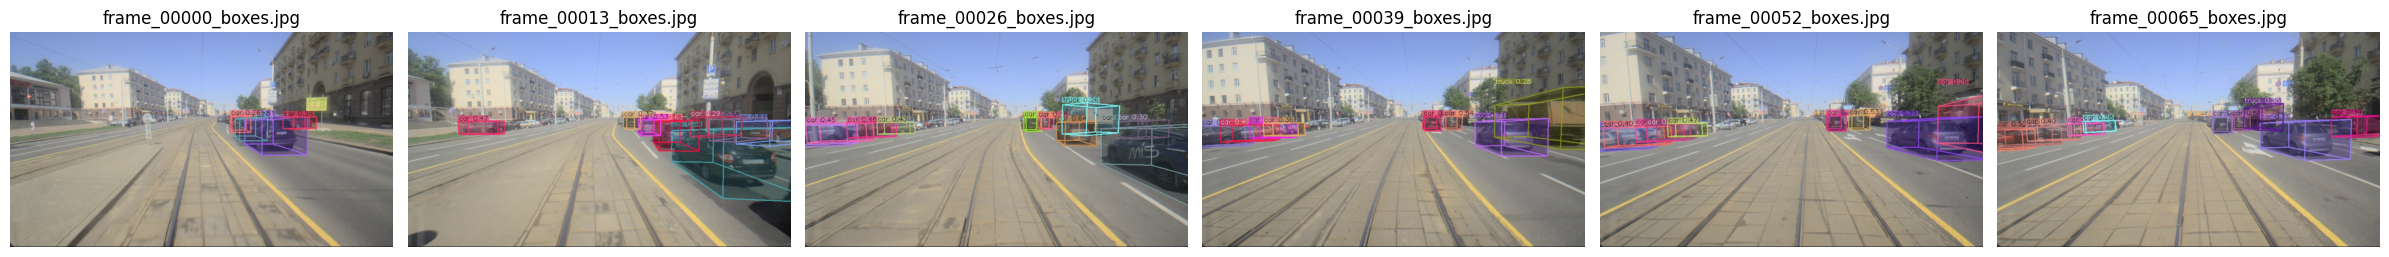

Всего кадров с разметкой: 79


In [29]:
import os
import glob
import matplotlib.pyplot as plt
from IPython.display import display
import cv2

result_images = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*_boxes.jpg")))
if not result_images:
    raise RuntimeError(f"Нет *_boxes.jpg в {OUTPUT_DIR}")

PREVIEW_COUNT = min(6, len(result_images))
step = max(1, len(result_images) // PREVIEW_COUNT)
preview = result_images[::step][:PREVIEW_COUNT]

fig, axes = plt.subplots(1, len(preview), figsize=(4 * len(preview), 4))
if len(preview) == 1:
    axes = [axes]
for ax, path in zip(axes, preview):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(os.path.basename(path))
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Всего кадров с разметкой: {len(result_images)}")

## 8. Сборка выходного MP4

In [33]:
import os
import glob
import subprocess
import sys

import cv2

try:
    import imageio_ffmpeg  # noqa: F401 — регистрирует FFMPEG в imageio
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "imageio", "imageio-ffmpeg"]
    )
    import imageio_ffmpeg  # noqa: F401

import imageio

result_images = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*_boxes.jpg")))
if not result_images:
    raise RuntimeError("Нет изображений для видео.")

first = cv2.cvtColor(cv2.imread(result_images[0]), cv2.COLOR_BGR2RGB)
h, w = first.shape[:2]
_cap = cv2.VideoCapture(VIDEO_PATH)
_fps = _cap.get(cv2.CAP_PROP_FPS) or 25.0
_cap.release()
fps_out = max(1.0, _fps / FRAME_STRIDE)

n_written = 0
with imageio.get_writer(
    OUT_VIDEO,
    fps=fps_out,
    codec="libx264",
    quality=8,
    macro_block_size=1,
) as writer:
    for path in result_images:
        bgr = cv2.imread(path)
        if bgr is None:
            continue
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        if rgb.shape[:2] != (h, w):
            rgb = cv2.resize(rgb, (w, h), interpolation=cv2.INTER_AREA)
        writer.append_data(rgb)
        n_written += 1

print("Видео:", OUT_VIDEO, f"({n_written} кадров, {fps_out:.1f} fps)")

try:
    from google.colab import files

    files.download(OUT_VIDEO)
except ImportError:
    pass

Видео: /content/omni3d_boxes.mp4 (79 кадров, 8.0 fps)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>